# Expanded Exploratory Data Analysis
This notebook builds on the initial draft so commuters and planners can see both day-to-day signals and broader monthly trends in LIRR delays and Long Island weather.


In [248]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from pandas.tseries.offsets import MonthEnd

sns.set_theme(style="whitegrid")

## Load and normalize raw data
**Purpose:** bring both datasets into a consistent, analysis-ready shape.
**How to read it:** this cell standardizes column names, parses timestamps, and creates helper fields (date, weekday, month, depart hour) so later plots are comparable. If any of these derived fields look off, fix the parsing here before moving on.


In [249]:
weather_df = (
    pd.read_csv(
        '../data/raw/Long_Island_Weather.csv',
        parse_dates=['DATE'],
    )
    .rename(columns=str.strip)
    .sort_values('DATE')
)


# Define dtypes for string columns only
string_cols = [
    'Train', 'Branch', 'Depart Station', 'Arrive Station', 'Period', 'Status', 'Delay Category'
]

# Read CSV with minimal initial dtype parsing for speed
lirr_df = pd.read_csv(
    '../data/raw/MTA_LIRR_Delays__Beginning_2010_20260122.csv',
    dtype={col: 'string' for col in string_cols},
    parse_dates=['Service Date'],
    low_memory=False
)

# Strip whitespace from column names
lirr_df.rename(columns=str.strip, inplace=True)

# Convert columns to correct types
lirr_df['Minutes Late'] = lirr_df['Minutes Late'].astype('Int64')

# Convert Depart/Arrive Time to datetime
lirr_df['Depart Time'] = pd.to_datetime(lirr_df['Depart Time'], format='%m/%d/%Y %I:%M:%S %p')
lirr_df['Arrive Time'] = pd.to_datetime(lirr_df['Arrive Time'], format='%m/%d/%Y %I:%M:%S %p')

# Add helpful temporal columns for analysis
lirr_df['date'] = lirr_df['Service Date'].dt.normalize()
lirr_df['weekday'] = lirr_df['Service Date'].dt.day_name()
lirr_df['month'] = lirr_df['Service Date'].dt.to_period('M')
lirr_df['year'] = lirr_df['Service Date'].dt.year

## Raw data snapshots
**Purpose:** sanity-check the data sources and confirm key columns exist.
**How to read it:** you should see representative rows from each dataset and a quick count of records. If shapes are unexpectedly tiny or columns are missing, fix the file paths or parsing before continuing.


In [250]:
print(f'LIRR records: {lirr_df.shape}')
print(f'LIRR Columns:', list(lirr_df.columns))
print(f'Weather records: {weather_df.shape}')
print(f'Weather Columns:', list(weather_df.columns))
display(lirr_df.head())
display(weather_df.head())

LIRR records: (254047, 15)
LIRR Columns: ['Service Date', 'Train', 'Branch', 'Depart Station', 'Depart Time', 'Arrive Station', 'Arrive Time', 'Period', 'Status', 'Minutes Late', 'Delay Category', 'date', 'weekday', 'month', 'year']
Weather records: (5839, 11)
Weather Columns: ['STATION', 'NAME', 'DATE', 'PRCP', 'SNOW', 'SNWD', 'TMAX', 'TMIN', 'TOBS', 'WESD', 'WT05']


,Service Date,Train,Branch,Depart Station,Depart Time,Arrive Station,Arrive Time,Period,Status,Minutes Late,Delay Category,date,weekday,month,year
0,2010-01-01,6148,Babylon,NY Penn Station,2010-01-01 23:31:00,Babylon,2010-01-01 00:47:00,Off-peak,Late,25,Police,2010-01-01,Friday,2010-01,2010
1,2010-01-01,6404,Port Washington,NY Penn Station,2010-01-01 03:20:00,Port Washington,2010-01-01 04:05:00,Off-peak,Late,11,Special Events,2010-01-01,Friday,2010-01,2010
2,2010-01-01,6405,Port Washington,Port Washington,2010-01-01 03:40:00,NY Penn Station,2010-01-01 04:25:00,Off-peak,Late,14,Special Events,2010-01-01,Friday,2010-01,2010
3,2010-01-01,6698,Port Jefferson,NY Penn Station,2010-01-01 03:13:00,Port Jefferson,2010-01-01 05:03:00,Off-peak,Late,26,Special Events,2010-01-01,Friday,2010-01,2010
4,2010-01-01,6702,Hempstead,Flatbush Avenue,2010-01-01 01:43:00,Hempstead,2010-01-01 02:34:00,Off-peak,Late,8,Special Events,2010-01-01,Friday,2010-01,2010


,STATION,NAME,DATE,PRCP,SNOW,SNWD,TMAX,TMIN,TOBS,WESD,WT05
0,USC00308721,"UPTON COOP NWSFO NEW YORK, NY US",2010-01-04,0.24,5.2,5.0,21.0,18.0,20.0,NaN,NaN
1,USC00308721,"UPTON COOP NWSFO NEW YORK, NY US",2010-01-05,0.00,0.0,3.0,32.0,19.0,19.0,NaN,NaN
2,USC00308721,"UPTON COOP NWSFO NEW YORK, NY US",2010-01-06,0.00,0.0,3.0,31.0,19.0,25.0,NaN,NaN
3,USC00308721,"UPTON COOP NWSFO NEW YORK, NY US",2010-01-07,0.00,0.0,3.0,34.0,24.0,27.0,NaN,NaN
4,USC00308721,"UPTON COOP NWSFO NEW YORK, NY US",2010-01-08,0.01,0.5,3.0,40.0,24.0,27.0,NaN,NaN


## Missingness and data types
**Purpose:** understand where gaps exist before visualizing or modeling.
**How to read it:** focus on columns with high missing percentages or unexpected dtypes (e.g., numbers stored as strings). Those are the prime candidates for cleaning or exclusion from modeling.


In [251]:
def missing_summary(df):
    return (
        df.isna()
        .sum()
        .to_frame(name='missing_count')
        .assign(missing_pct=lambda x: x['missing_count'] / len(df) * 100)
        .sort_values('missing_pct', ascending=False)
    )

display(missing_summary(weather_df).head(6))
display(missing_summary(lirr_df).head(6))

,missing_count,missing_pct
WT05,5837,99.965748
WESD,5797,99.280699
SNOW,15,0.256893
PRCP,13,0.222641
SNWD,12,0.205515
TMIN,9,0.154136


,missing_count,missing_pct
Minutes Late,21584,8.496066
Delay Category,1062,0.418033
Service Date,0,0.000000
Depart Station,0,0.000000
Depart Time,0,0.000000
Train,0,0.000000


In [252]:
# Fill missing precipitation/snow data
weather_df[['PRCP', 'SNOW', 'SNWD']] = weather_df[['PRCP', 'SNOW', 'SNWD']].fillna(0)

# Total precipitation (rain + snow)
weather_df['PRCP_TOTAL'] = (weather_df['PRCP'] + weather_df['SNOW']).round(2)

# Drop unnecessary columns
cols_to_drop = ['WESD', 'WT05', 'TOBS', 'STATION', 'NAME']
weather_df = weather_df.drop(columns=cols_to_drop).sort_values('DATE')

# Rolling 7-day temperature averages and fill missing values
for col in ['TMIN', 'TMAX']:
    weather_df[col] = (
        weather_df[col]
        .fillna(weather_df[col].rolling(window=7, center=True, min_periods=1).mean().apply(np.ceil))
    )

display(missing_summary(weather_df).head(6))

,missing_count,missing_pct
DATE,0,0.0
PRCP,0,0.0
SNOW,0,0.0
SNWD,0,0.0
TMAX,0,0.0
TMIN,0,0.0


In [253]:
print(lirr_df['Status'].value_counts())

print(f'\nLate summary:', lirr_df[lirr_df['Status'] == 'Late']['Minutes Late'].describe())
print(f'\nCancelled summary:', lirr_df[lirr_df['Status'] == 'Cancelled']['Minutes Late'].describe())
print(f'\nPartial Cancel summary:', lirr_df[lirr_df['Status'] == 'Partial Cancel']['Minutes Late'].describe())

Status
Late              230029
Cancelled          14939
Partial Cancel      9079
Name: count, dtype: Int64

Late summary: count     230029.0
mean      12.47624
std      10.977295
min            6.0
25%            7.0
50%            9.0
75%           13.0
max          427.0
Name: Minutes Late, dtype: Float64

Cancelled summary: count     0.0
mean     <NA>
std      <NA>
min      <NA>
25%      <NA>
50%      <NA>
75%      <NA>
max      <NA>
Name: Minutes Late, dtype: Float64

Partial Cancel summary: count       2434.0
mean     25.470008
std      25.416516
min            6.0
25%           10.0
50%           16.0
75%           30.0
max          223.0
Name: Minutes Late, dtype: Float64


In [254]:
lirr_df = lirr_df[~lirr_df['Status'].isin(['Partial Cancel', 'Cancelled'])]
display(missing_summary(lirr_df).head(6))

,missing_count,missing_pct
Delay Category,5,0.002174
Train,0,0.000000
Service Date,0,0.000000
Depart Station,0,0.000000
Depart Time,0,0.000000
Arrive Station,0,0.000000


In [255]:
# Looking at if all possible stations are recorded. There are 126 unique train stations that make up the LIRR system
print(lirr_df['Depart Station'].value_counts())
print('-'*60)
print(lirr_df['Arrive Station'].value_counts())
print('-'*60)

# What are all the possible Delay Categories?
print(lirr_df['Delay Category'].value_counts())

Depart Station
NY Penn Station    65479
Babylon            25323
Huntington         17903
Ronkonkoma         17164
Jamaica            12880
                   ...  
Seaford                2
Storage Yard           2
Garden City            2
Woodside               1
East Hampton           1
Name: count, Length: 67, dtype: Int64
------------------------------------------------------------
Arrive Station
NY Penn Station      81880
Babylon              19748
Huntington           19160
Ronkonkoma           13602
Atlantic Terminal    10195
                     ...  
Stony Brook              2
Elmont-UBS Arena         2
Queens Village           1
Amityville               1
Woodside                 1
Name: count, Length: 63, dtype: Int64
------------------------------------------------------------
Delay Category
Customers                     36178
Police                        26972
Engineering (Unscheduled)     23251
Weather & Environmental       22167
Maintenance of Equipment      19193
Other

In [256]:
# Added a simple list for all the possible stations to compare
all_stations = pd.read_csv("../data/raw/all_stations.txt", header=None)
all_stations = pd.Series(all_stations[0])

observed_stations = lirr_df['Depart Station'].value_counts()

missing_stations = (
    all_stations[~all_stations.isin(observed_stations.index)]
)

print(f"Observed: {observed_stations.shape[0]}")
print(f"Missing: {missing_stations.shape[0]}")
print('\nTrains leaving from these stations have never been recorded late. This could cause problems for training.\n')
print(missing_stations.tolist())


Observed: 67
Missing: 67

Trains leaving from these stations have never been recorded late. This could cause problems for training.

['Albertson', 'Auburndale', 'Baldwin', 'Bay Shore', 'Bellerose', 'Bellmore', 'Bellport', 'Broadway', 'Carle Place', 'Cedarhurst', 'Centre Avenue', 'Copiague', 'Country Life Press', 'Douglaston', 'East New York', 'East Rockaway', 'Flushing-Main Street', 'Forest Hills', 'Gibson', 'Glen Cove', 'Glen Head', 'Glen Street', 'Grand Central Madison', 'Great River', 'Greenlawn', 'Greenvale', 'Hempstead Gardens', 'Hewlett', 'Hollis', 'Hunterspoint Avenue', 'Inwood', 'Islip', 'Kew Gardens', 'Kings Park', 'Lakeview', 'Laurelton', 'Lawrence', 'Locust Manor', 'Malverne', 'Manhasset', 'Mastic-Shirley', 'Mattituck', 'Medford', 'Merillon Avenue', 'Murray Hill', 'Nassau Boulevard', 'New Hyde Park', 'Northport', 'Nostrand Avenue', 'Oakdale', 'Oceanside', 'Penn Station', 'Pinelawn', 'Plandome', 'Queens Village', 'Rosedale', 'Roslyn', 'Sea Cliff', 'Southold', 'St. Albans', 'S

### Branches
Perhaps the dataset only covers some branches

In [257]:
# Branches listed on Wikipedia
print('Main Trunk Branches: Main Line, Montauk Branch, Atlantic Branch')
print('Minor Branches: Port Washington, Port Jefferson, Hempstead, Oyster Bay, Central, Far Rockaway, Long Beach.')
print(f'Branches included in dataset: ', lirr_df['Branch'].value_counts())

Main Trunk Branches: Main Line, Montauk Branch, Atlantic Branch
Minor Branches: Port Washington, Port Jefferson, Hempstead, Oyster Bay, Central, Far Rockaway, Long Beach.
Branches included in dataset:  Branch
Babylon               44415
Ronkonkoma            33963
Huntington            32004
Port Washington       24974
Montauk               22530
Port Jefferson        17621
Long Beach            15080
Hempstead             13044
Far Rockaway           9911
Oyster Bay             9853
West Hempstead         5346
City Terminal Zone     1288
Name: count, dtype: Int64


### Branch Layout
The dataset wraps many of the major roots together as 'City Terminal Zone' and then splits some of the branches into their service names (like  Babylon vs Montauk).
Here is a basic diagram that we can explore later:

# LIRR Branch Map (Electrified vs Diesel) running East to West
Manhattan / City Terminal Zone (Electrified)

  +-- Port Washington Branch (Electrified)
       Woodside --> Port Washington

  +-- Ronkonkoma Branch (Main Branch)
       Woodside --> Jamaica (Electrified, City Terminal Zone)
       Jamaica --> Hicksville --> Ronkonkoma (Electrified)
            East of Ronkonkoma --> Greenport (Diesel)

  +-- Montauk Branch / Babylon Branch
       Jamaica --> Babylon (Electrified, Babylon Branch)
       Babylon --> Montauk (Diesel)

  +-- Port Jefferson Branch
       Hicksville --> Huntington (Electrified)
       Huntington --> Port Jefferson (Diesel)

  +-- Hempstead Branch (Electrified)
       Elmont --> Hempstead

  +-- West Hempstead Branch (Electrified)
       Valley Stream --> West Hempstead

  +-- Long Beach Branch (Electrified)
       Valley Stream --> Long Beach

  +-- Far Rockaway Branch (Electrified)
       Valley Stream --> Far Rockaway

  +-- Oyster Bay Branch
       Mineola --> East Williston (Electrified)
       East Williston --> Oyster Bay (Diesel)

## Problematic Trains

In [258]:
print(lirr_df['Train'].value_counts())

Train
665     1116
461      894
1715     854
2061     824
133      806
        ... 
9654       1
259        1
8843       1
8924       1
8879       1
Name: count, Length: 2991, dtype: Int64


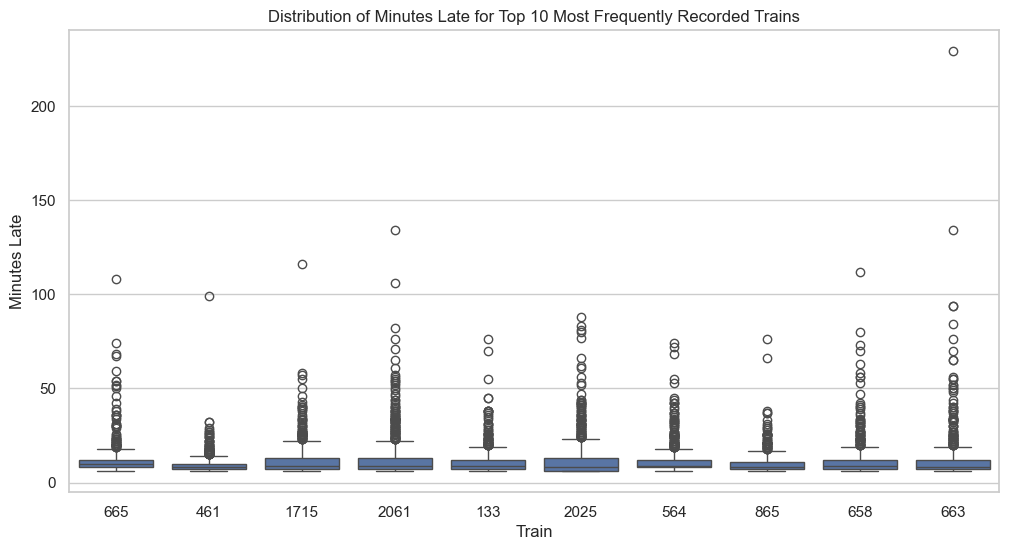

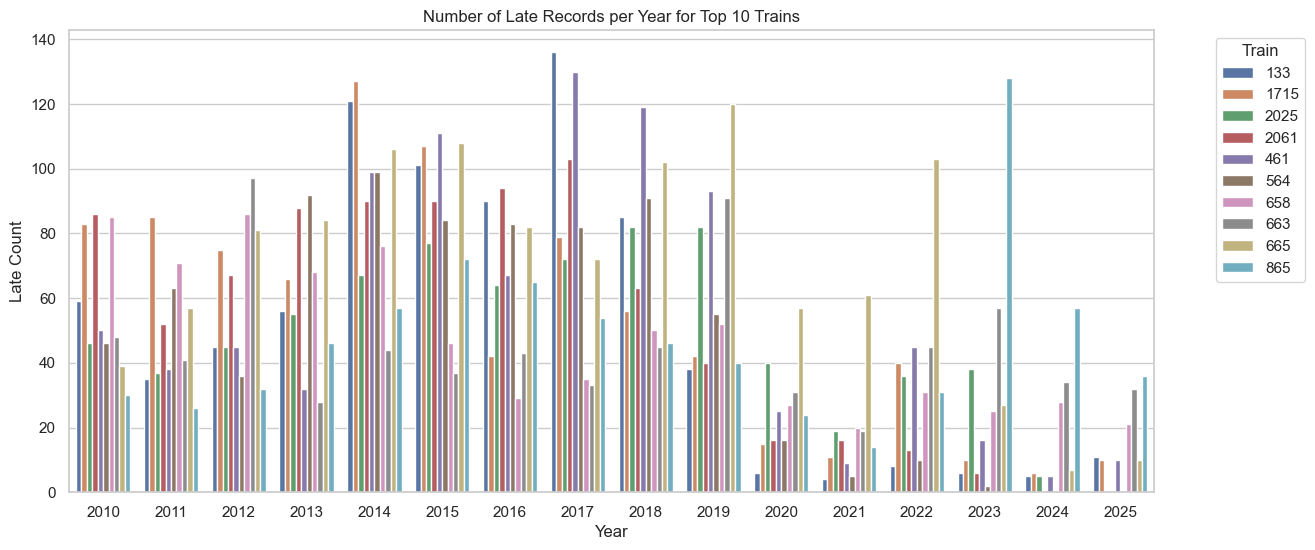

In [259]:
top_trains = lirr_df['Train'].value_counts().head(10).index

# Filter for these top 10 trains
df_top = lirr_df[lirr_df['Train'].isin(top_trains)].copy()

# Boxplot of Minutes Late per Train
plt.figure(figsize=(12, 6))
sns.boxplot(
    data=df_top,
    x='Train',
    y='Minutes Late',
    order=top_trains
)
plt.title('Distribution of Minutes Late for Top 10 Most Frequently Recorded Trains')
plt.xlabel('Train')
plt.ylabel('Minutes Late')
plt.show()

# Late counts per Train per Year
late_counts = (
    df_top
    .groupby(['Train', 'year'])
    .size()
    .reset_index(name='late_count')
)

plt.figure(figsize=(14, 6))
sns.barplot(
    data=late_counts,
    x='year',
    y='late_count',
    hue='Train'
)
plt.title('Number of Late Records per Year for Top 10 Trains')
plt.xlabel('Year')
plt.ylabel('Late Count')
plt.legend(title='Train', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

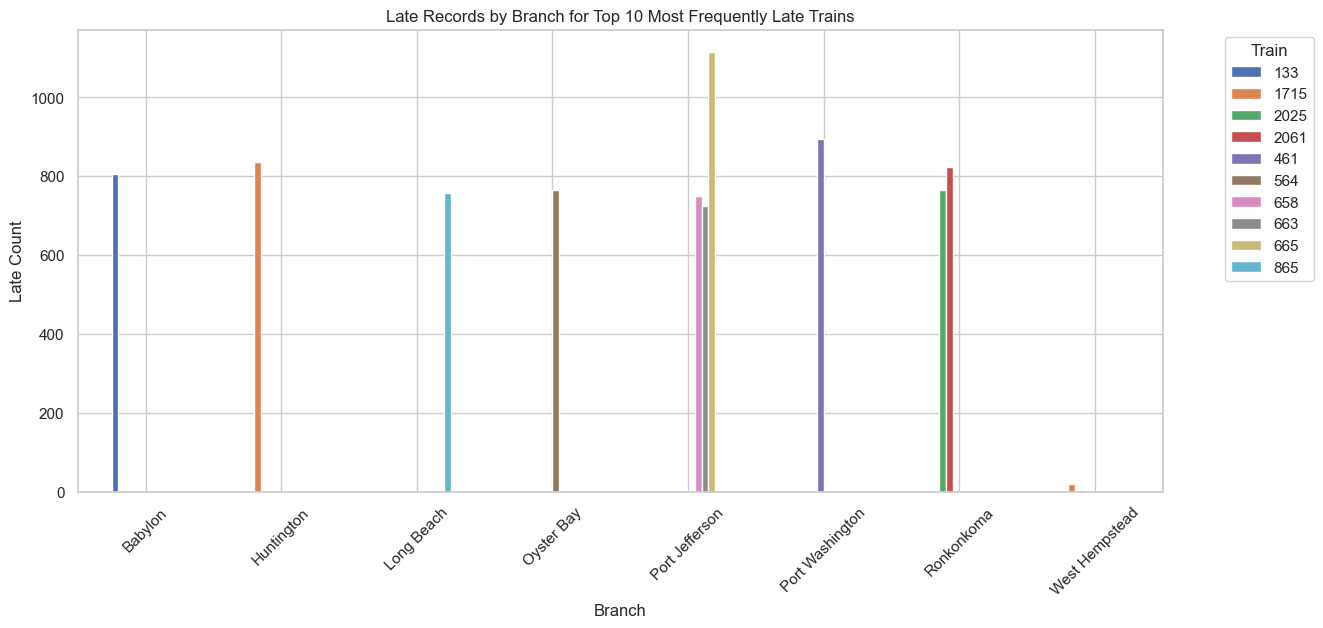

   Train           Branch  late_count
0    133          Babylon         806
1   1715       Huntington         835
2   1715   West Hempstead          19
3   2025       Ronkonkoma         765
4   2061       Ronkonkoma         824
5    461  Port Washington         894
6    564       Oyster Bay         764
7    658   Port Jefferson         750
8    663   Port Jefferson         725
9    665   Port Jefferson        1116
10   865       Long Beach         758


In [260]:
# Count the number of late records per Train per Branch
branch_counts = (
    df_top
    .groupby(['Train', 'Branch'])
    .size()
    .reset_index(name='late_count')
)

# Pivot for better plotting
branch_pivot = branch_counts.pivot(index='Branch', columns='Train', values='late_count').fillna(0)

# Plot as a grouped bar chart
branch_pivot.plot(
    kind='bar',
    figsize=(14, 6),
)
plt.title('Late Records by Branch for Top 10 Most Frequently Late Trains')
plt.xlabel('Branch')
plt.ylabel('Late Count')
plt.xticks(rotation=45)
plt.legend(title='Train', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

# Print summary table
print(branch_counts.sort_values(['Train', 'late_count'], ascending=[True, False]))


In [261]:
train_val = "665"  # string
train665_data = lirr_df[lirr_df['Train'] == train_val]
print(train665_data['Branch'].value_counts())

Branch
Port Jefferson    1116
Name: count, dtype: Int64


## Delay profile by branch and category
**Purpose:** identify which branches and delay categories dominate the dataset.
**How to read it:** the histogram shows the overall tail of late minutes; the branch boxplots compare typical delay sizes across busy lines; the bar chart reveals the most common delay causes. Look for skewed distributions or branches with noticeably higher medians.


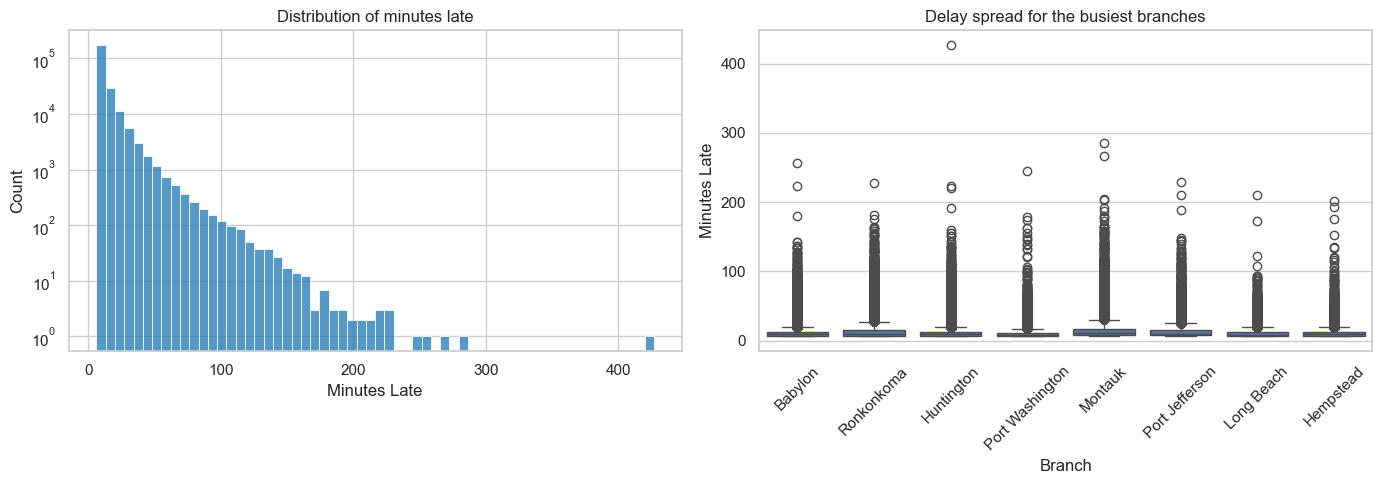

In [262]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(
    data=lirr_df,
    x='Minutes Late',
    bins=60,
    ax=axes[0],
    color='tab:blue',
)
axes[0].set_yscale("log") # Fixed the log scale so graph shows up
axes[0].set_title('Distribution of minutes late')
axes[0].set_xlabel('Minutes Late')

branch_order = (
    lirr_df['Branch']
    .value_counts()
    .nlargest(8)
    .index
)
sns.boxplot(
    data=lirr_df[lirr_df['Branch'].isin(branch_order)],
    x='Branch',
    y='Minutes Late',
    order=branch_order,
    ax=axes[1],
)
axes[1].set_title('Delay spread for the busiest branches')
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()


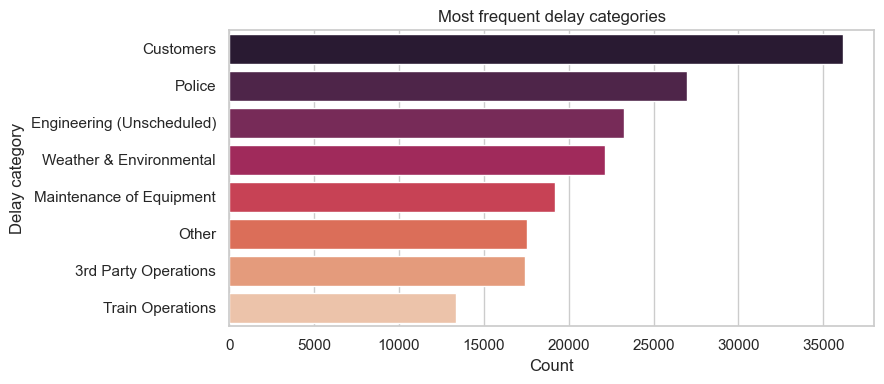

In [263]:
delay_category_counts = lirr_df['Delay Category'].value_counts().nlargest(8)
fig, ax = plt.subplots(figsize=(9, 4))
sns.barplot(
    x=delay_category_counts.values,
    y=delay_category_counts.index,
    hue=delay_category_counts.index,
    palette='rocket',
    ax=ax,
    legend=False,
)
ax.set_title('Most frequent delay categories')
ax.set_xlabel('Count')
ax.set_ylabel('Delay category')
plt.tight_layout()

## Temporal summaries (daily, weekday, monthly)
**Purpose:** capture day-to-day variability and longer-term patterns.
**How to read it:** weekday bars highlight routine schedule effects, while the monthly line plot shows seasonality or trend changes. Spikes in the monthly series can signal operational or weather-driven shifts.


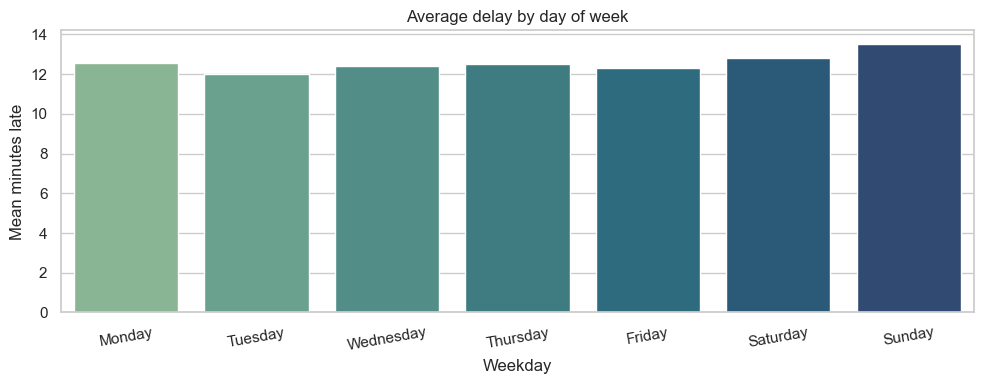

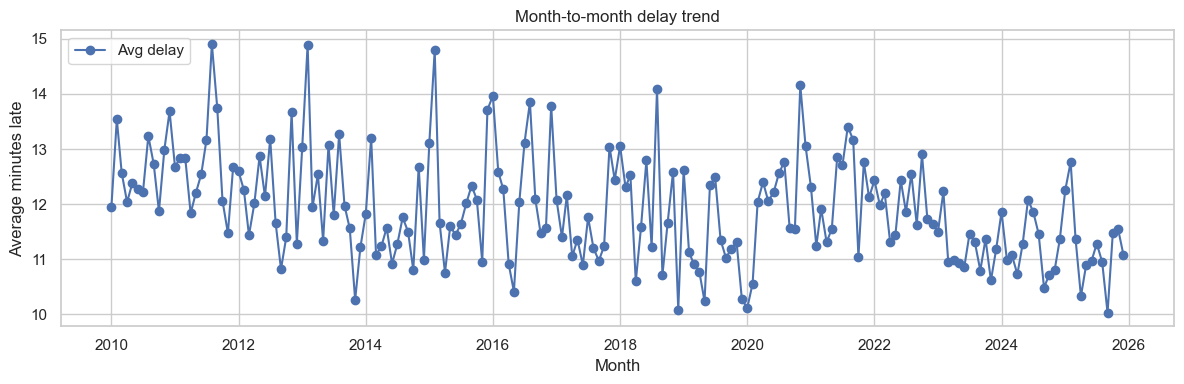

In [264]:
daily_summary = (
    lirr_df.groupby('date')
    .agg(
        total_trips=('Train', 'count'),
        avg_delay=('Minutes Late', 'mean'),
        median_delay=('Minutes Late', 'median'),
    )
)

weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekday_summary = (
    lirr_df.groupby('weekday')
    .agg(avg_delay=('Minutes Late', 'mean'))
    .reindex(weekday_order)
)

# Plot average delay by weekday
fig, ax = plt.subplots(figsize=(10, 4))
sns.barplot(
    data=weekday_summary.reset_index(),
    x='weekday',
    y='avg_delay',
    hue='weekday',
    palette='crest',
    ax=ax,
    legend=False,
)
ax.set_title('Average delay by day of week')
ax.set_ylabel('Mean minutes late')
ax.set_xlabel('Weekday')
ax.tick_params(axis='x', rotation=10)
plt.tight_layout()

# Monthly summary
monthly_summary = (
    daily_summary
    .reset_index()
    .assign(month=lambda df: df['date'].dt.to_period('M'))
    .groupby('month')
    .agg(avg_delay=('avg_delay', 'mean'))
    .reset_index()
)
monthly_summary['month_start'] = monthly_summary['month'].dt.to_timestamp()

# Plot month-to-month delay trend
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(monthly_summary['month_start'], monthly_summary['avg_delay'], label='Avg delay', marker='o')
ax.set_title('Month-to-month delay trend')
ax.set_ylabel('Average minutes late')
ax.set_xlabel('Month')
ax.legend(loc='upper left')
plt.tight_layout()

## Temporal summaries (Holidays)
**Purpose:** Capture increased delays due to holidays and seasons.
**How to read it:** Average delay per week per year over an arbitrary calendar year

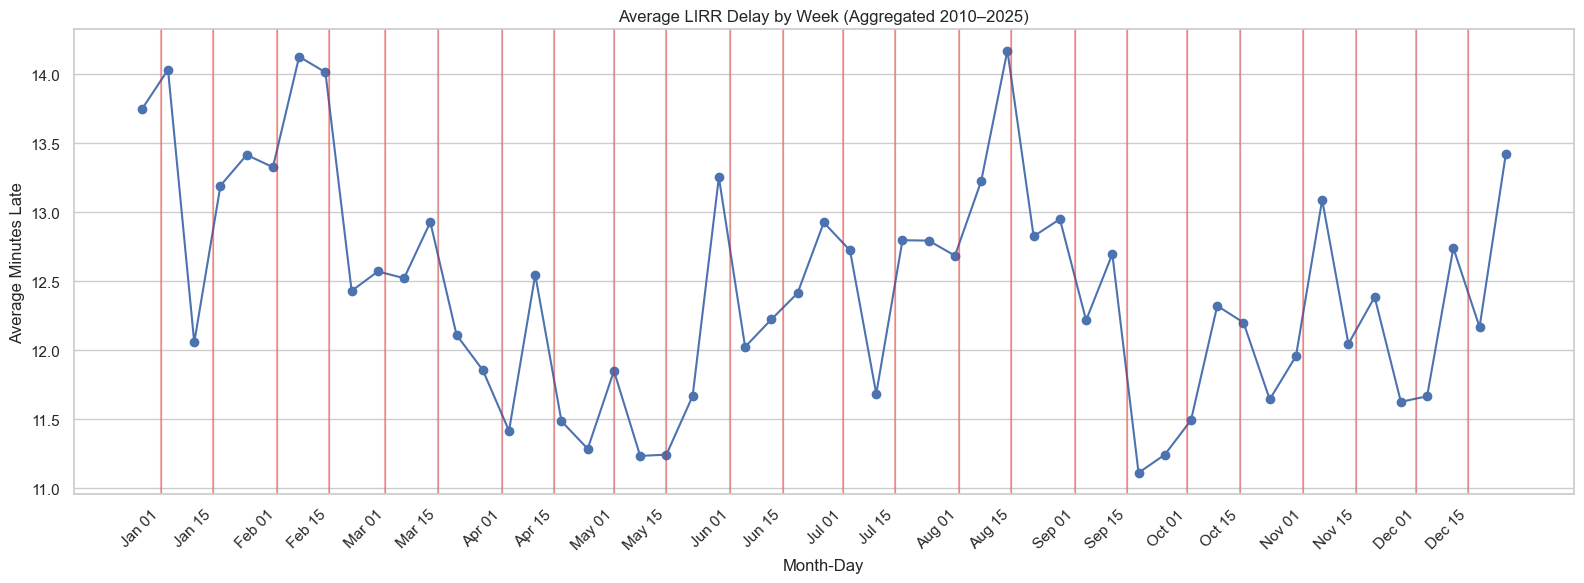

In [265]:
# Assign each date to its week in an arbitrary year (2000)
lirr_df['week_start'] = lirr_df['date'].apply(
    lambda d: pd.Timestamp(year=2000, month=d.month, day=d.day)
).dt.to_period('W').apply(lambda p: p.start_time)

# Aggregate weekly average delay across all years
weekly_avg = (
    lirr_df.groupby('week_start')
    .agg(avg_delay=('Minutes Late', 'mean'))
    .reset_index()
)

# Generate 1st and 15th of each month in year 2000
firsts = pd.date_range('2000-01-01', '2000-12-01', freq='MS')
fifteenths = firsts + pd.Timedelta(days=14)
marker_dates = firsts.union(fifteenths)

# Plot
fig, ax = plt.subplots(figsize=(16,6))

ax.plot(weekly_avg['week_start'], weekly_avg['avg_delay'], marker='o', label='Avg Delay')

# Add vertical lines for 1st and 15th
for dt in marker_dates:
    ax.axvline(dt, color='red', alpha=0.3)

ax.set_title('Average LIRR Delay by Week (Aggregated 2010–2025)')
ax.set_xlabel('Month-Day')
ax.set_ylabel('Average Minutes Late')

# Optional: rotate x-axis labels
ax.set_xticks(marker_dates)
ax.set_xticklabels([dt.strftime('%b %d') for dt in marker_dates], rotation=45, ha='right')

plt.tight_layout()
plt.show()

## Temporal Analysis Covid

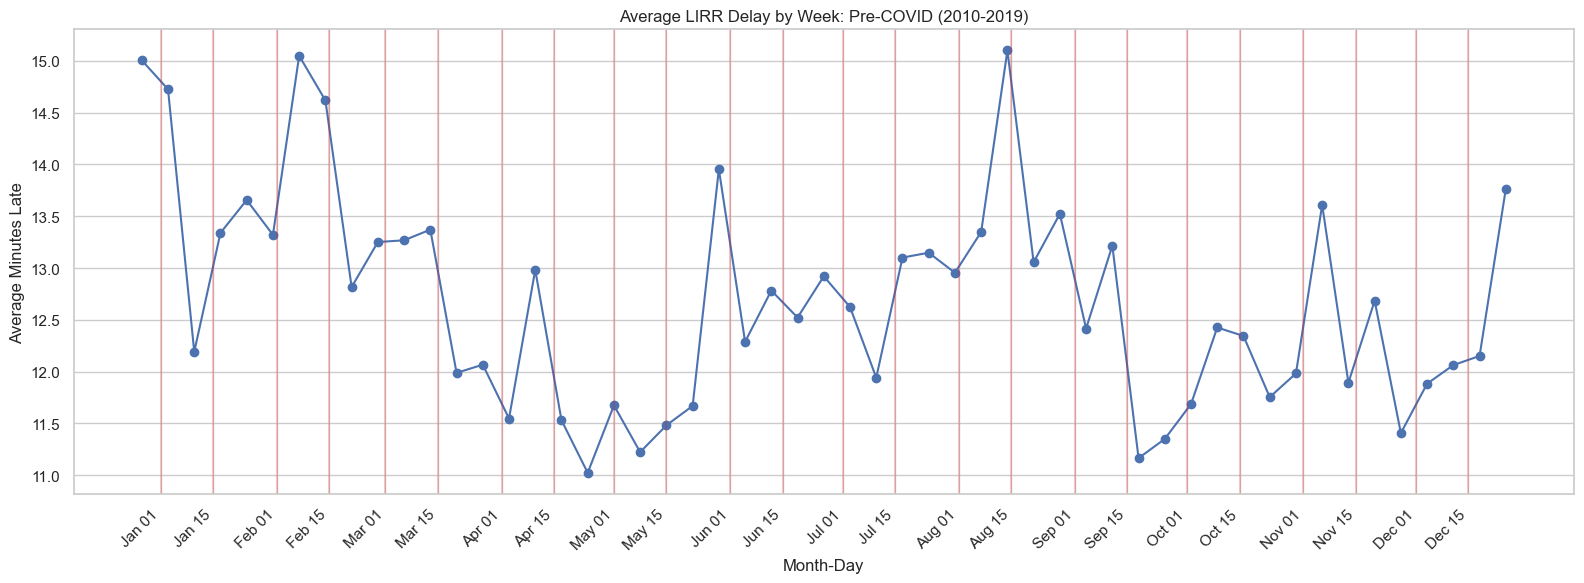

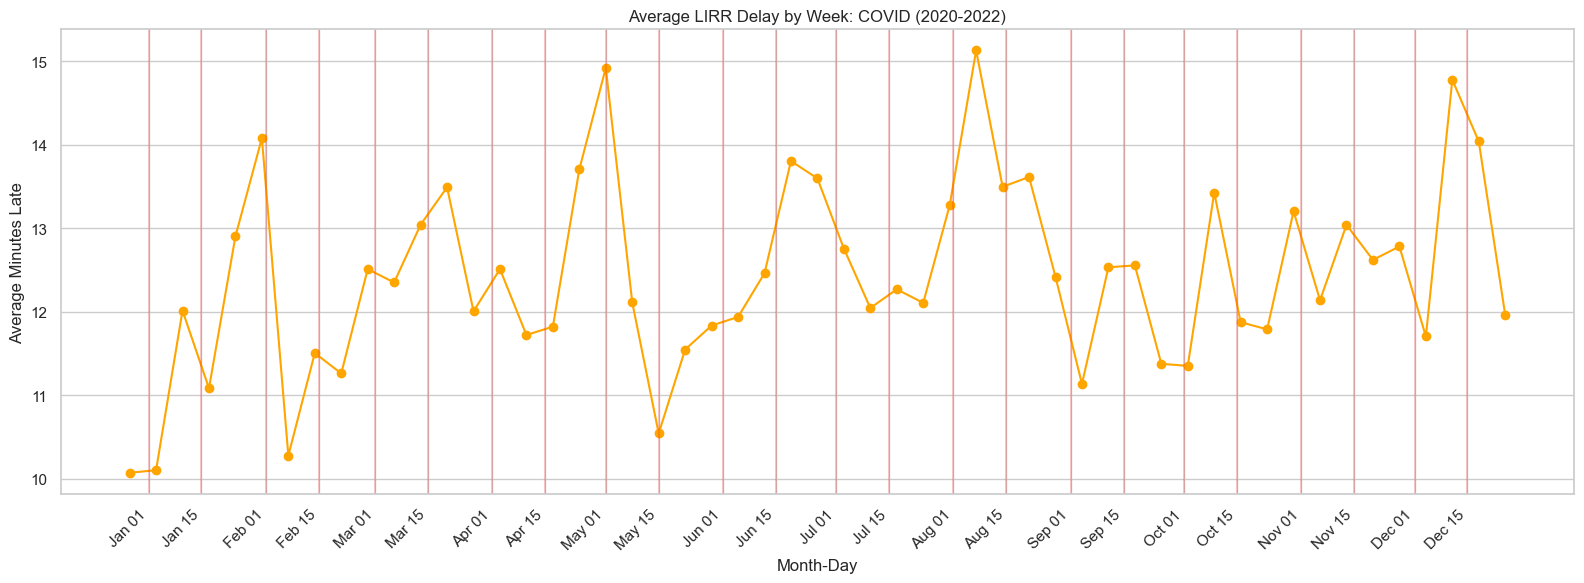

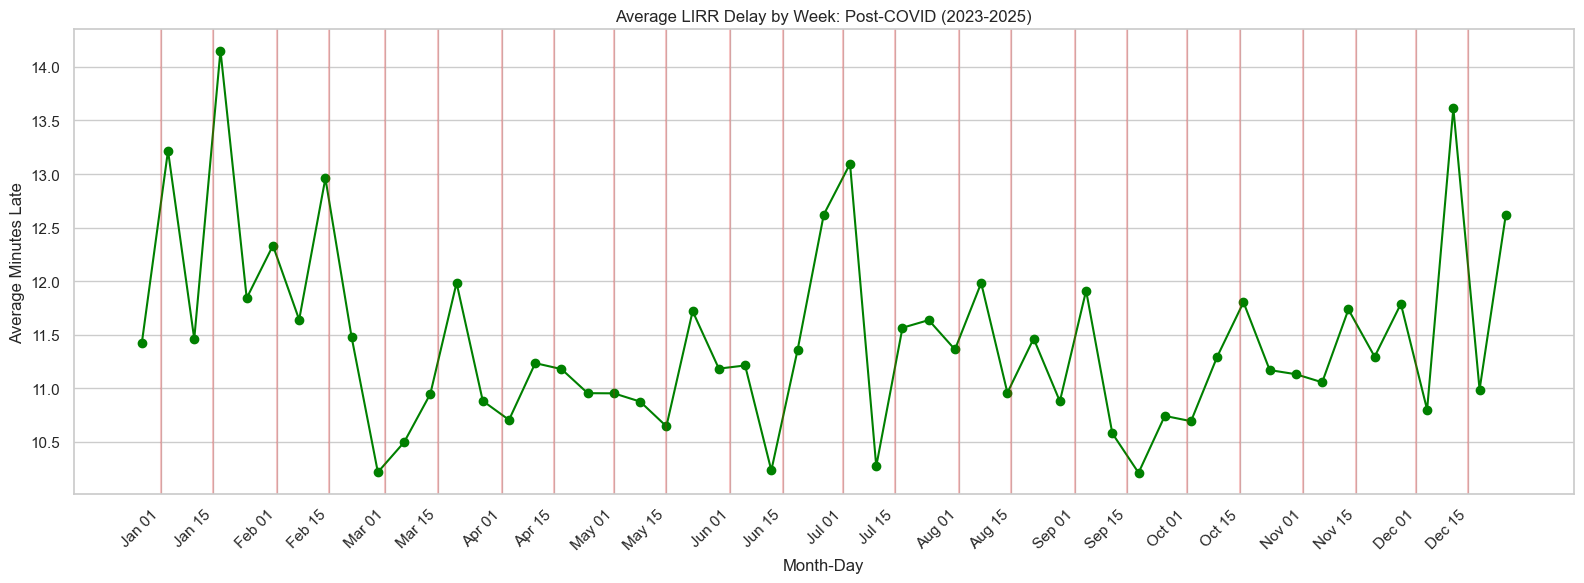

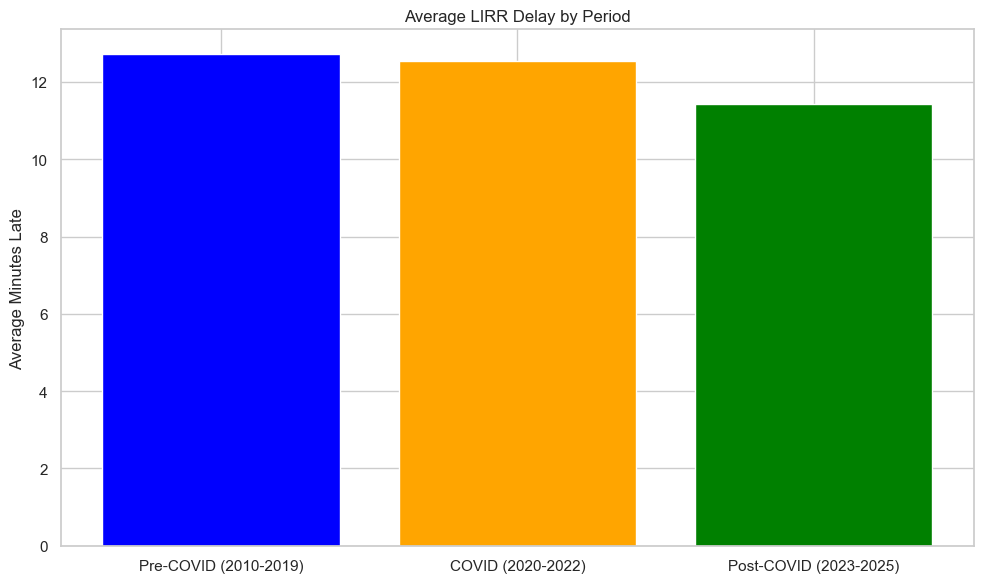

In [266]:
# Split into periods
pre_covid = lirr_df[(lirr_df['year'] >= 2010) & (lirr_df['year'] <= 2019)]
covid = lirr_df[(lirr_df['year'] >= 2020) & (lirr_df['year'] <= 2022)]
post_covid = lirr_df[(lirr_df['year'] >= 2023) & (lirr_df['year'] <= 2025)]

# Function to compute weekly averages
def weekly_avg_delays(df):
    df = df.copy()
    df['week_start'] = df['date'].apply(
        lambda d: pd.Timestamp(year=2000, month=d.month, day=d.day)
    ).dt.to_period('W').apply(lambda p: p.start_time)
    
    weekly_avg = df.groupby('week_start').agg(avg_delay=('Minutes Late', 'mean')).reset_index()
    return weekly_avg

# Compute weekly averages
pre_avg = weekly_avg_delays(pre_covid)
covid_avg = weekly_avg_delays(covid)
post_avg = weekly_avg_delays(post_covid)

# Create 1st and 15th of each month for markers
firsts = pd.date_range('2000-01-01', '2000-12-01', freq='MS')
fifteenths = firsts + pd.Timedelta(days=14)
marker_dates = firsts.union(fifteenths)

# Plot Pre-COVID
fig, ax = plt.subplots(figsize=(16,6))
ax.plot(pre_avg['week_start'], pre_avg['avg_delay'], marker='o', label='Pre-COVID (2010-2019)')
for dt in marker_dates:
    ax.axvline(dt, color='red', alpha=0.2)
ax.set_title('Average LIRR Delay by Week: Pre-COVID (2010-2019)')
ax.set_xlabel('Month-Day')
ax.set_ylabel('Average Minutes Late')
ax.set_xticks(marker_dates)
ax.set_xticklabels([dt.strftime('%b %d') for dt in marker_dates], rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Plot COVID
fig, ax = plt.subplots(figsize=(16,6))
ax.plot(covid_avg['week_start'], covid_avg['avg_delay'], marker='o', label='COVID (2020-2022)', color='orange')
for dt in marker_dates:
    ax.axvline(dt, color='red', alpha=0.2)
ax.set_title('Average LIRR Delay by Week: COVID (2020-2022)')
ax.set_xlabel('Month-Day')
ax.set_ylabel('Average Minutes Late')
ax.set_xticks(marker_dates)
ax.set_xticklabels([dt.strftime('%b %d') for dt in marker_dates], rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Plot Post-COVID
fig, ax = plt.subplots(figsize=(16,6))
ax.plot(post_avg['week_start'], post_avg['avg_delay'], marker='o', label='Post-COVID (2023-2025)', color='green')
for dt in marker_dates:
    ax.axvline(dt, color='red', alpha=0.2)
ax.set_title('Average LIRR Delay by Week: Post-COVID (2023-2025)')
ax.set_xlabel('Month-Day')
ax.set_ylabel('Average Minutes Late')
ax.set_xticks(marker_dates)
ax.set_xticklabels([dt.strftime('%b %d') for dt in marker_dates], rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Overall average delay comparison
avg_delays = [
    pre_covid['Minutes Late'].mean(),
    covid['Minutes Late'].mean(),
    post_covid['Minutes Late'].mean()
]
periods = ['Pre-COVID (2010-2019)', 'COVID (2020-2022)', 'Post-COVID (2023-2025)']

fig, ax = plt.subplots(figsize=(10,6))
ax.bar(periods, avg_delays, color=['blue', 'orange', 'green'])
ax.set_ylabel('Average Minutes Late')
ax.set_title('Average LIRR Delay by Period')
plt.tight_layout()
plt.show()

## Investigating Outliers

In [267]:
# Filter rows where 'Minutes Late' > 180
extreme_delays = lirr_df[lirr_df['Minutes Late'] > 180]

extreme_delays

,Service Date,Train,Branch,Depart Station,Depart Time,Arrive Station,Arrive Time,Period,Status,Minutes Late,Delay Category,date,weekday,month,year,week_start
10550,2010-08-23,1635,Huntington,Huntington,2010-08-23 10:04:00,NY Penn Station,2010-08-23 11:12:00,Off-peak,Late,221,Other,2010-08-23,Monday,2010-08,2010,2000-08-21
10551,2010-08-23,1637,Huntington,Huntington,2010-08-23 11:04:00,NY Penn Station,2010-08-23 12:12:00,Off-peak,Late,223,Other,2010-08-23,Monday,2010-08,2010,2000-08-21
10592,2010-08-23,2039,Ronkonkoma,Ronkonkoma,2010-08-23 10:11:00,NY Penn Station,2010-08-23 11:32:00,Off-peak,Late,228,Other,2010-08-23,Monday,2010-08,2010,2000-08-21
10649,2010-08-23,2831,Far Rockaway,Far Rockaway,2010-08-23 10:36:00,Flatbush Avenue,2010-08-23 11:33:00,Off-peak,Late,198,Other,2010-08-23,Monday,2010-08,2010,2000-08-21
10685,2010-08-23,515,Oyster Bay,Oyster Bay,2010-08-23 10:37:00,Jamaica,2010-08-23 11:33:00,Off-peak,Late,225,Other,2010-08-23,Monday,2010-08,2010,2000-08-21
10708,2010-08-23,59,Babylon,Babylon,2010-08-23 10:06:00,NY Penn Station,2010-08-23 11:07:00,Off-peak,Late,256,Other,2010-08-23,Monday,2010-08,2010,2000-08-21
10714,2010-08-23,63,Babylon,Babylon,2010-08-23 10:48:00,NY Penn Station,2010-08-23 12:02:00,Off-peak,Late,223,Other,2010-08-23,Monday,2010-08,2010,2000-08-21
10739,2010-08-23,733,Hempstead,Hempstead,2010-08-23 11:11:00,Flatbush Avenue,2010-08-23 12:03:00,Off-peak,Late,202,Other,2010-08-23,Monday,2010-08,2010,2000-08-21
10766,2010-08-23,833,Long Beach,Long Beach,2010-08-23 10:53:00,NY Penn Station,2010-08-23 11:44:00,Off-peak,Late,211,Other,2010-08-23,Monday,2010-08,2010,2000-08-21
46551,2013-02-08,663,Port Jefferson,Port Jefferson,2013-02-08 21:41:00,Hicksville,2013-02-08 22:46:00,Off-peak,Late,229,Weather & Environmental,2013-02-08,Friday,2013-02,2013,2000-02-07


## Weather highlights
**Purpose:** summarize the seasonal weather patterns that may affect service.
**How to read it:** compare temperature curves with precipitation totals. Large precipitation peaks or extreme temperature ranges suggest months that could plausibly increase delays.


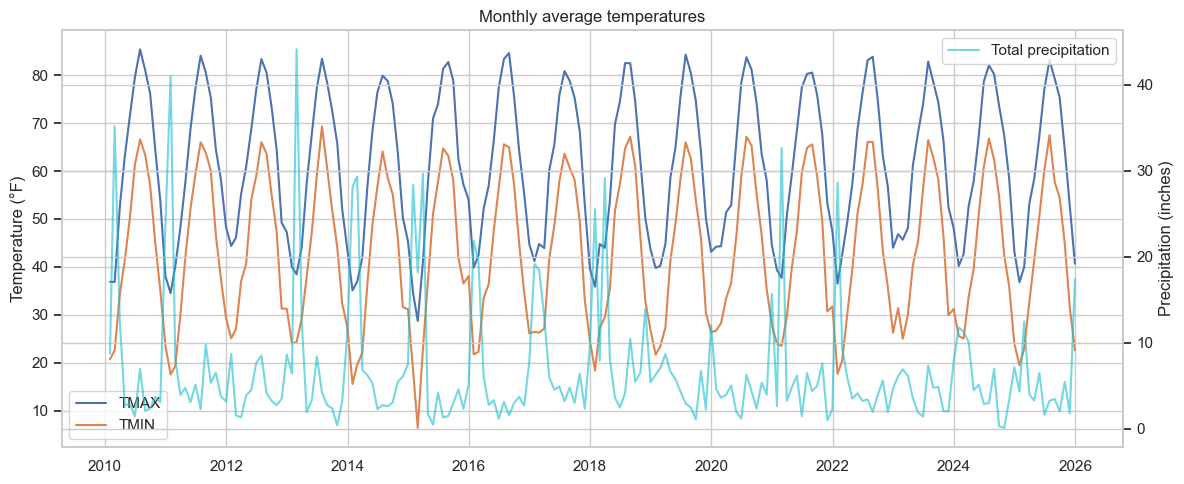

In [268]:
weather_monthly = (
    weather_df.set_index('DATE')
    .resample('ME')
    .agg(
        precipitation=('PRCP_TOTAL', 'sum'),
        tmax=('TMAX', 'mean'),
        tmin=('TMIN', 'mean'),
    )
)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(weather_monthly.index, weather_monthly['tmax'], label='TMAX')
ax.plot(weather_monthly.index, weather_monthly['tmin'], label='TMIN')
ax.set_title('Monthly average temperatures')
ax.set_ylabel('Temperature (°F)')
ax.legend()
ax2 = ax.twinx()
ax2.plot(
    weather_monthly.index,
    weather_monthly['precipitation'],
    label='Total precipitation',
    color='tab:cyan',
    alpha=0.6,
)
ax2.set_ylabel('Precipitation (inches)')
ax2.legend(loc='upper right')
plt.tight_layout()


## Weather vs. delay relationships
**Purpose:** test whether delays rise in tandem with weather severity.
**How to read it:** the correlation heatmap provides a quick directional check, while the precipitation vs. delay plot shows if heavier rain corresponds to higher average delays. Weak or noisy relationships here imply weather may be only one of several drivers.


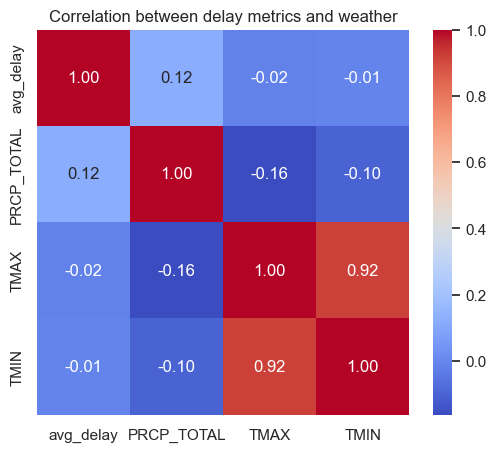

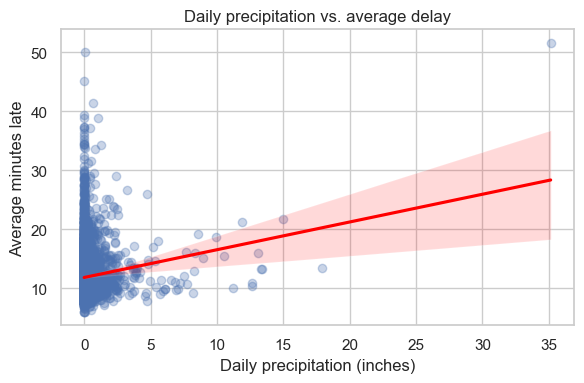

In [269]:
weather_daily = (
    weather_df.set_index('DATE')
    .resample('D')
    .agg(PRCP_TOTAL=('PRCP_TOTAL', 'sum'), TMAX=('TMAX', 'max'), TMIN=('TMIN', 'min'))
)

combined = (
    daily_summary
    .join(weather_daily, how='inner')
    .dropna(subset=['avg_delay', 'PRCP_TOTAL', 'TMAX', 'TMIN'])
)

corr = combined[['avg_delay', 'PRCP_TOTAL', 'TMAX', 'TMIN']].corr()
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', ax=ax)
ax.set_title('Correlation between delay metrics and weather')

fig, ax = plt.subplots(figsize=(6, 4))
sns.regplot(
    data=combined,
    x='PRCP_TOTAL',
    y='avg_delay',
    scatter_kws={'alpha': 0.3},
    line_kws={'color': 'red'},
    ax=ax,
)
ax.set_title('Daily precipitation vs. average delay')
ax.set_xlabel('Daily precipitation (inches)')
ax.set_ylabel('Average minutes late')
plt.tight_layout()

## Example of Clean Train Data

In [270]:
clean_lirr_df = pd.read_csv('../data/processed/lirr_train_clean_late.csv', low_memory=False)

dtype warning

In [271]:
# Show all columns and their types
print(clean_lirr_df.dtypes)

service_date       object
train              object
branch             object
depart_station     object
arrive_station     object
minutes_late      float64
dtype: object


Can either drop unneeded columns or convert them

In [272]:
print(f'LIRR records:\n', lirr_df['Minutes Late'].describe())
print(f'\nClean LIRR records:\n', clean_lirr_df['minutes_late'].describe())

LIRR records:
 count     230029.0
mean      12.47624
std      10.977295
min            6.0
25%            7.0
50%            9.0
75%           13.0
max          427.0
Name: Minutes Late, dtype: Float64

Clean LIRR records:
 count    230029.000000
mean         12.473375
std          10.913835
min           6.000000
25%           7.000000
50%           9.000000
75%          13.000000
max         200.000000
Name: minutes_late, dtype: float64


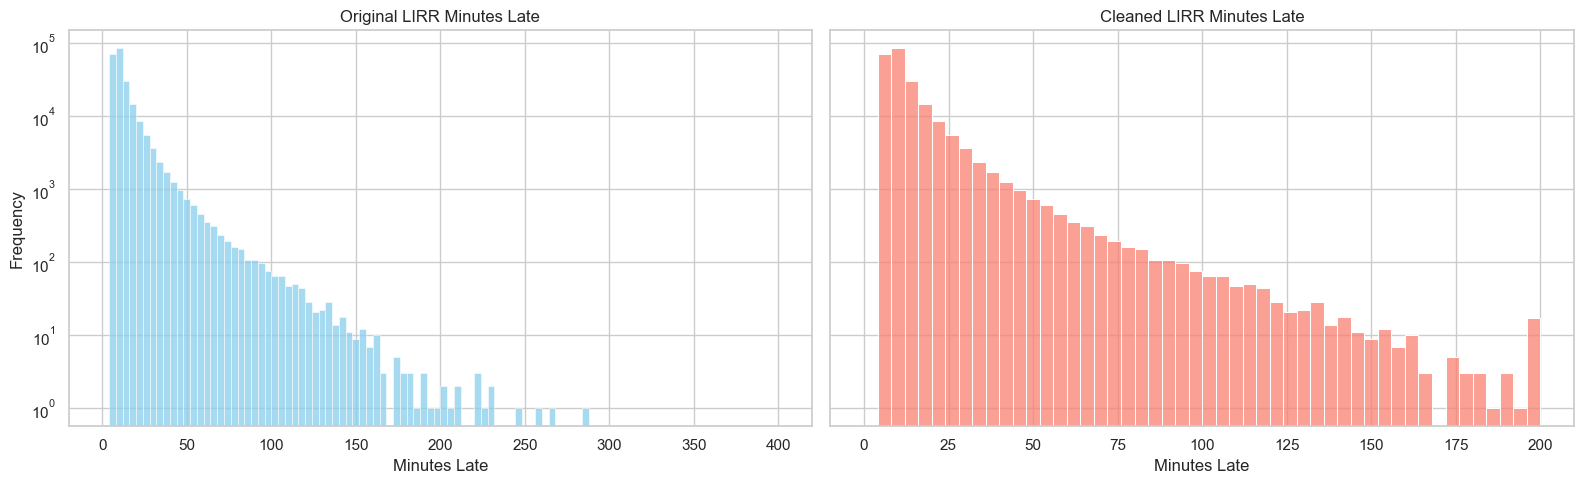

In [273]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

# Histogram for original LIRR dataset
sns.histplot(
    lirr_df['Minutes Late'],
    bins=100,
    binrange=(0, 400),
    color='skyblue',
    kde=False,
    ax=axes[0]
)
axes[0].set_yscale("log") # Fixed the log scale so graph shows up
axes[0].set_title('Original LIRR Minutes Late')
axes[0].set_xlabel('Minutes Late')
axes[0].set_ylabel('Frequency')

# Histogram for cleaned LIRR dataset
sns.histplot(
    clean_lirr_df['minutes_late'],
    bins=50,
    binrange=(0, 200),
    color='salmon',
    kde=False,
    ax=axes[1]
)
axes[1].set_yscale("log") # Fixed the log scale so graph shows up
axes[1].set_title('Cleaned LIRR Minutes Late')
axes[1].set_xlabel('Minutes Late')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

In [274]:
# Filter rows where Minutes Late < 6
small_delays = lirr_df[lirr_df['Minutes Late'] < 6]
clean_small_delays = clean_lirr_df[clean_lirr_df['minutes_late'] < 6]

# Print all values
print("Number of trips with Minutes Late <= 6:", len(small_delays))
print("Number of clean trips with Minutes Late <= 6:", len(clean_small_delays))

Number of trips with Minutes Late <= 6: 0
Number of clean trips with Minutes Late <= 6: 0


## Rerun Regression with Transform

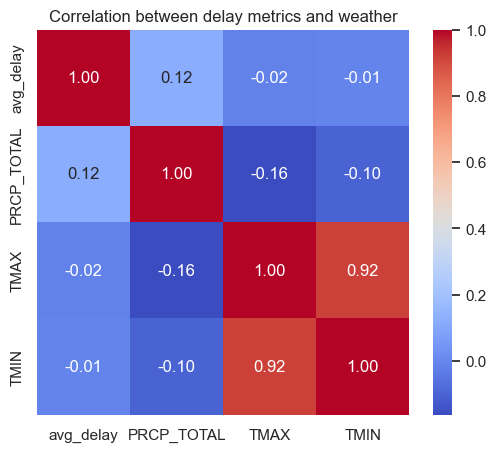

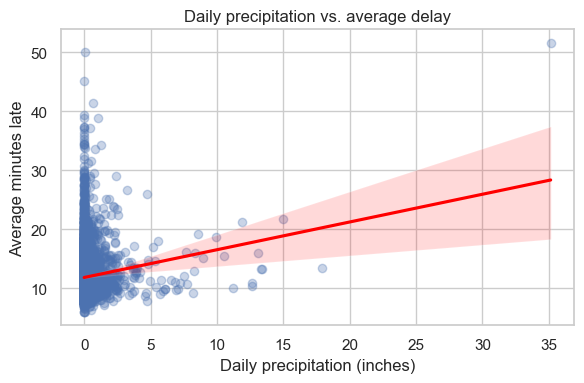

In [275]:
# Log Transform
lirr_df['Minutes Late Log'] = np.log(lirr_df['Minutes Late'])

daily_summary = (
    lirr_df.groupby('date')
    .agg(
        total_trips=('Train', 'count'),
        avg_delay=('Minutes Late', 'mean'),
        median_delay=('Minutes Late', 'median'),
    )
)

weather_daily = (
    weather_df.set_index('DATE')
    .resample('D')
    .agg(PRCP_TOTAL=('PRCP_TOTAL', 'sum'), TMAX=('TMAX', 'max'), TMIN=('TMIN', 'min'))
)

combined = (
    daily_summary
    .join(weather_daily, how='inner')
    .dropna(subset=['avg_delay', 'PRCP_TOTAL', 'TMAX', 'TMIN'])
)

corr = combined[['avg_delay', 'PRCP_TOTAL', 'TMAX', 'TMIN']].corr()
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', ax=ax)
ax.set_title('Correlation between delay metrics and weather')

fig, ax = plt.subplots(figsize=(6, 4))
sns.regplot(
    data=combined,
    x='PRCP_TOTAL',
    y='avg_delay',
    scatter_kws={'alpha': 0.3},
    line_kws={'color': 'red'},
    ax=ax,
)
ax.set_title('Daily precipitation vs. average delay')
ax.set_xlabel('Daily precipitation (inches)')
ax.set_ylabel('Average minutes late')
plt.tight_layout()